In [11]:
import os, sys, time, json, random, warnings, math
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device.upper()}')
if device == 'cuda':
    props = torch.cuda.get_device_properties(0)
    free  = (props.total_memory - torch.cuda.memory_allocated()) / 1e9
    print(f'GPU : {props.name}')
    print(f'VRAM: {props.total_memory/1e9:.1f} GB total  |  {free:.1f} GB free')

Device: CUDA
GPU : NVIDIA RTX 4000 Ada Generation
VRAM: 21.5 GB total  |  15.7 GB free


In [12]:
# ── Dataset CSV paths (your local Windows paths) ──────────────────────────────
LA_META        = r'D:\1230079\dataset\LA\LA\meta.csv'
ITW_META       = r'D:\1230079\dataset\In_the_wild\meta.csv'
DEEPFAKE_META  = r'D:\1230079\dataset\Deepfake-Eval-2024\audio-metadata-publish.csv'

# ── Where to save checkpoints locally ────────────────────────────────────────
P1_SAVE_DIR = r'D:\1230079\checkpoints\parent1_la'
P2_SAVE_DIR = r'D:\1230079\checkpoints\parent2_itw'

import os
os.makedirs(P1_SAVE_DIR, exist_ok=True)
os.makedirs(P2_SAVE_DIR, exist_ok=True)

# ── Verify all input paths exist ──────────────────────────────────────────────
all_ok = True
for label, p in [('LA meta',               LA_META),
                 ('In-the-Wild meta',      ITW_META),
                 ('Deepfake-Eval meta',    DEEPFAKE_META)]:
    exists = os.path.isfile(p)
    print(f'{"✅" if exists else "❌"} {label}: {p}')
    if not exists:
        all_ok = False

print()
for label, p in [('P1 checkpoint dir', P1_SAVE_DIR),
                 ('P2 checkpoint dir', P2_SAVE_DIR)]:
    print(f'✅ {label}: {p}')

if not all_ok:
    raise FileNotFoundError('One or more dataset paths are missing. Fix paths above.')
print('\n✅ All paths verified.')


✅ LA meta: D:\1230079\dataset\LA\LA\meta.csv
✅ In-the-Wild meta: D:\1230079\dataset\In_the_wild\meta.csv
✅ Deepfake-Eval meta: D:\1230079\dataset\Deepfake-Eval-2024\audio-metadata-publish.csv

✅ P1 checkpoint dir: D:\1230079\checkpoints\parent1_la
✅ P2 checkpoint dir: D:\1230079\checkpoints\parent2_itw

✅ All paths verified.


In [13]:
# Paste the full contents of your model.py here.
# (SincConv, Residual_block, RawNet — exactly as in model.py)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import numpy as np
import math
from torch.utils import data
from collections import OrderedDict
from torch.nn.parameter import Parameter
from torch.autograd import Variable
import pickle
import random


class SincConv(nn.Module):
    @staticmethod
    def to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        return 700 * (10 ** (mel / 2595) - 1)


    def __init__(self, device,out_channels, kernel_size,in_channels=1,sample_rate=16000,
                 stride=1, padding=0, dilation=1, bias=False, groups=1,freq_scale='Mel'):

        super(SincConv,self).__init__()


        if in_channels != 1:
            
            msg = "SincConv only support one input channel (here, in_channels = {%i})" % (in_channels)
            raise ValueError(msg)
        
        self.out_channels = out_channels+1
        self.kernel_size = kernel_size
        self.sample_rate=sample_rate

        # Forcing the filters to be odd (i.e, perfectly symmetrics)
        if kernel_size%2==0:
            self.kernel_size=self.kernel_size+1

        self.device=device   
        self.stride = stride
        self.padding = padding
        self.dilation = dilation
        
        if bias:
            raise ValueError('SincConv does not support bias.')
        if groups > 1:
            raise ValueError('SincConv does not support groups.')
        
        
        # initialize filterbanks using Mel scale
        NFFT = 512
        f=int(self.sample_rate/2)*np.linspace(0,1,int(NFFT/2)+1)


        if freq_scale == 'Mel':
            fmel=self.to_mel(f) # Hz to mel conversion
            fmelmax=np.max(fmel)
            fmelmin=np.min(fmel)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            filbandwidthsf=self.to_hz(filbandwidthsmel) # Mel to Hz conversion
            self.freq=filbandwidthsf[:self.out_channels]

        elif freq_scale == 'Inverse-mel':
            fmel=self.to_mel(f) # Hz to mel conversion
            fmelmax=np.max(fmel)
            fmelmin=np.min(fmel)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            filbandwidthsf=self.to_hz(filbandwidthsmel) # Mel to Hz conversion
            self.mel=filbandwidthsf[:self.out_channels]
            self.freq=np.abs(np.flip(self.mel)-1) ## invert mel scale

        
        else:
            fmelmax=np.max(f)
            fmelmin=np.min(f)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            self.freq=filbandwidthsmel[:self.out_channels]
        
        self.hsupp=torch.arange(-(self.kernel_size-1)/2, (self.kernel_size-1)/2+1)
        self.band_pass=torch.zeros(self.out_channels-1,self.kernel_size)
    
       
        
    def forward(self,x):
        for i in range(len(self.freq)-1):
            fmin=self.freq[i]
            fmax=self.freq[i+1]
            hHigh=(2*fmax/self.sample_rate)*np.sinc(2*fmax*self.hsupp/self.sample_rate)
            hLow=(2*fmin/self.sample_rate)*np.sinc(2*fmin*self.hsupp/self.sample_rate)
            hideal=hHigh-hLow
            
            self.band_pass[i,:]=Tensor(np.hamming(self.kernel_size))*Tensor(hideal)
        
        band_pass_filter=self.band_pass.to(self.device)

        self.filters = (band_pass_filter).view(self.out_channels-1, 1, self.kernel_size)
        
        return F.conv1d(x, self.filters, stride=self.stride,
                        padding=self.padding, dilation=self.dilation,
                         bias=None, groups=1)


        
class Residual_block(nn.Module):
    def __init__(self, nb_filts, first = False):
        super(Residual_block, self).__init__()
        self.first = first
        
        if not self.first:
            self.bn1 = nn.BatchNorm1d(num_features = nb_filts[0])
        
        self.lrelu = nn.LeakyReLU(negative_slope=0.3)
        
        self.conv1 = nn.Conv1d(in_channels = nb_filts[0],
			out_channels = nb_filts[1],
			kernel_size = 3,
			padding = 1,
			stride = 1)
        
        self.bn2 = nn.BatchNorm1d(num_features = nb_filts[1])
        self.conv2 = nn.Conv1d(in_channels = nb_filts[1],
			out_channels = nb_filts[1],
			padding = 1,
			kernel_size = 3,
			stride = 1)
        
        if nb_filts[0] != nb_filts[1]:
            self.downsample = True
            self.conv_downsample = nn.Conv1d(in_channels = nb_filts[0],
				out_channels = nb_filts[1],
				padding = 0,
				kernel_size = 1,
				stride = 1)
            
        else:
            self.downsample = False
        self.mp = nn.MaxPool1d(3)
        
    def forward(self, x):
        identity = x
        if not self.first:
            out = self.bn1(x)
            out = self.lrelu(out)
        else:
            out = x
            
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.lrelu(out)
        out = self.conv2(out)
        
        if self.downsample:
            identity = self.conv_downsample(identity)
            
        out += identity
        out = self.mp(out)
        return out





class RawNet(nn.Module):
    def __init__(self, d_args, device):
        super(RawNet, self).__init__()

        
        self.device=device

        self.Sinc_conv=SincConv(device=self.device,
			out_channels = d_args['filts'][0],
			kernel_size = d_args['first_conv'],
                        in_channels = d_args['in_channels'],freq_scale='Mel'
        )
        
        self.first_bn = nn.BatchNorm1d(num_features = d_args['filts'][0])
        self.selu = nn.SELU(inplace=True)
        self.block0 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1], first = True))
        self.block1 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1]))
        self.block2 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        d_args['filts'][2][0] = d_args['filts'][2][1]
        self.block3 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.block4 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.block5 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        self.fc_attention0 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention1 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention2 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention3 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention4 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention5 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])

        self.bn_before_gru = nn.BatchNorm1d(num_features = d_args['filts'][2][-1])
        self.gru = nn.GRU(input_size = d_args['filts'][2][-1],
			hidden_size = d_args['gru_node'],
			num_layers = d_args['nb_gru_layer'],
			batch_first = True)

        
        self.fc1_gru = nn.Linear(in_features = d_args['gru_node'],
			out_features = d_args['nb_fc_node'])
       
        self.fc2_gru = nn.Linear(in_features = d_args['nb_fc_node'],
			out_features = d_args['nb_classes'],bias=True)
			
       
        self.sig = nn.Sigmoid()
        
        
    def forward(self, x, y = None,is_test=False):
        
        
        nb_samp = x.shape[0]
        len_seq = x.shape[1]
        x=x.view(nb_samp,1,len_seq)
        
        x = self.Sinc_conv(x)    # Fixed sinc filters convolution
        x = F.max_pool1d(torch.abs(x), 3)
        x = self.first_bn(x)
        x = self.selu(x)
        
        x0 = self.block0(x)
        y0 = self.avgpool(x0).view(x0.size(0), -1) # torch.Size([batch, filter])
        y0 = self.fc_attention0(y0)
        y0 = self.sig(y0).view(y0.size(0), y0.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x0 * y0 + y0  # (batch, filter, time) x (batch, filter, 1)
        

        x1 = self.block1(x)
        y1 = self.avgpool(x1).view(x1.size(0), -1) # torch.Size([batch, filter])
        y1 = self.fc_attention1(y1)
        y1 = self.sig(y1).view(y1.size(0), y1.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x1 * y1 + y1 # (batch, filter, time) x (batch, filter, 1)

        x2 = self.block2(x)
        y2 = self.avgpool(x2).view(x2.size(0), -1) # torch.Size([batch, filter])
        y2 = self.fc_attention2(y2)
        y2 = self.sig(y2).view(y2.size(0), y2.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x2 * y2 + y2 # (batch, filter, time) x (batch, filter, 1)

        x3 = self.block3(x)
        y3 = self.avgpool(x3).view(x3.size(0), -1) # torch.Size([batch, filter])
        y3 = self.fc_attention3(y3)
        y3 = self.sig(y3).view(y3.size(0), y3.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x3 * y3 + y3 # (batch, filter, time) x (batch, filter, 1)

        x4 = self.block4(x)
        y4 = self.avgpool(x4).view(x4.size(0), -1) # torch.Size([batch, filter])
        y4 = self.fc_attention4(y4)
        y4 = self.sig(y4).view(y4.size(0), y4.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x4 * y4 + y4 # (batch, filter, time) x (batch, filter, 1)

        x5 = self.block5(x)
        y5 = self.avgpool(x5).view(x5.size(0), -1) # torch.Size([batch, filter])
        y5 = self.fc_attention5(y5)
        y5 = self.sig(y5).view(y5.size(0), y5.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x5 * y5 + y5 # (batch, filter, time) x (batch, filter, 1)

        x = self.bn_before_gru(x)
        x = self.selu(x)
        x = x.permute(0, 2, 1)     #(batch, filt, time) >> (batch, time, filt)
        self.gru.flatten_parameters()
        x, _ = self.gru(x)
        x = x[:,-1,:]
        x = self.fc1_gru(x)
        x = self.fc2_gru(x)

        if not is_test:
            output = x
            return output

        else:
            output=F.softmax(x,dim=1)
            return output
      
       
        

    def _make_attention_fc(self, in_features, l_out_features):

        l_fc = []
        
        l_fc.append(nn.Linear(in_features = in_features,
			        out_features = l_out_features))

        

        return nn.Sequential(*l_fc)


    def _make_layer(self, nb_blocks, nb_filts, first = False):
        layers = []
        #def __init__(self, nb_filts, first = False):
        for i in range(nb_blocks):
            first = first if i == 0 else False
            layers.append(Residual_block(nb_filts = nb_filts,
				first = first))
            if i == 0: nb_filts[0] = nb_filts[1]
            
        return nn.Sequential(*layers)

    def summary(self, input_size, batch_size=-1, device="cuda", print_fn = None):
        if print_fn == None: printfn = print
        model = self
        
        def register_hook(module):
            def hook(module, input, output):
                class_name = str(module.__class__).split(".")[-1].split("'")[0]
                module_idx = len(summary)
                
                m_key = "%s-%i" % (class_name, module_idx + 1)
                summary[m_key] = OrderedDict()
                summary[m_key]["input_shape"] = list(input[0].size())
                summary[m_key]["input_shape"][0] = batch_size
                if isinstance(output, (list, tuple)):
                    summary[m_key]["output_shape"] = [
						[-1] + list(o.size())[1:] for o in output
					]
                else:
                    summary[m_key]["output_shape"] = list(output.size())
                    if len(summary[m_key]["output_shape"]) != 0:
                        summary[m_key]["output_shape"][0] = batch_size
                        
                params = 0
                if hasattr(module, "weight") and hasattr(module.weight, "size"):
                    params += torch.prod(torch.LongTensor(list(module.weight.size())))
                    summary[m_key]["trainable"] = module.weight.requires_grad
                if hasattr(module, "bias") and hasattr(module.bias, "size"):
                    params += torch.prod(torch.LongTensor(list(module.bias.size())))
                summary[m_key]["nb_params"] = params
                
            if (
				not isinstance(module, nn.Sequential)
				and not isinstance(module, nn.ModuleList)
				and not (module == model)
			):
                hooks.append(module.register_forward_hook(hook))
                
        device = device.lower()
        assert device in [
			"cuda",
			"cpu",
		], "Input device is not valid, please specify 'cuda' or 'cpu'"
        
        if device == "cuda" and torch.cuda.is_available():
            dtype = torch.cuda.FloatTensor
        else:
            dtype = torch.FloatTensor
        if isinstance(input_size, tuple):
            input_size = [input_size]
        x = [torch.rand(2, *in_size).type(dtype) for in_size in input_size]
        summary = OrderedDict()
        hooks = []
        model.apply(register_hook)
        model(*x)
        for h in hooks:
            h.remove()
            
        print_fn("----------------------------------------------------------------")
        line_new = "{:>20}  {:>25} {:>15}".format("Layer (type)", "Output Shape", "Param #")
        print_fn(line_new)
        print_fn("================================================================")
        total_params = 0
        total_output = 0
        trainable_params = 0
        for layer in summary:
            # input_shape, output_shape, trainable, nb_params
            line_new = "{:>20}  {:>25} {:>15}".format(
				layer,
				str(summary[layer]["output_shape"]),
				"{0:,}".format(summary[layer]["nb_params"]),
			)
            total_params += summary[layer]["nb_params"]
            total_output += np.prod(summary[layer]["output_shape"])
            if "trainable" in summary[layer]:
                if summary[layer]["trainable"] == True:
                    trainable_params += summary[layer]["nb_params"]
            print_fn(line_new)

d_args = {
    'in_channels'  : 1,
    'first_conv'   : 128,
    'filts'        : [128, [128, 128], [128, 512], [512, 512]],
    'nb_fc_node'   : 1024,
    'gru_node'     : 1024,
    'nb_gru_layer' : 3,
    'nb_classes'   : 2,
}
print('✅ RawNet2 architecture defined.')

✅ RawNet2 architecture defined.


In [14]:
TARGET_SR = 16000
MAX_LEN   = 64600    # ~4 sec at 16 kHz

# ─────────────────────────────────────────────────────────────────────────────
# Padding helpers
# ─────────────────────────────────────────────────────────────────────────────

def pad_random(x, max_len=MAX_LEN):
    """Random-offset crop/pad — prevents position-dependent artifact learning."""
    x_len = x.shape[0]
    if x_len >= max_len:
        start = random.randint(0, x_len - max_len)
        return x[start : start + max_len]
    return np.tile(x, math.ceil(max_len / x_len))[:max_len]

def pad_fixed(x, max_len=MAX_LEN):
    """Deterministic pad for evaluation."""
    x_len = x.shape[0]
    if x_len >= max_len:
        return x[:max_len]
    return np.tile(x, math.ceil(max_len / x_len))[:max_len]

# ─────────────────────────────────────────────────────────────────────────────
# Parent 1 augmentation — light, clean-domain preserving
# ─────────────────────────────────────────────────────────────────────────────

def augment_p1(x, sr=TARGET_SR):
    # Volume scaling 0.8×–1.2×
    x = x * random.uniform(0.8, 1.2)
    # Gaussian noise SNR 20–40 dB (50% chance)
    if random.random() < 0.5:
        snr_db    = random.uniform(20, 40)
        sig_pwr   = np.mean(x ** 2) + 1e-9
        noise_pwr = sig_pwr / (10 ** (snr_db / 10))
        x = x + np.random.normal(0, math.sqrt(noise_pwr), x.shape)
    return x.astype(np.float32)

# ─────────────────────────────────────────────────────────────────────────────
# Parent 2 augmentation — aggressive, in-the-wild simulation
# ─────────────────────────────────────────────────────────────────────────────

def simulate_codec(x, sr=TARGET_SR):
    """Simulate MP3 compression via ffmpeg round-trip."""
    import subprocess, tempfile
    tmp_wav = tempfile.mktemp(suffix='.wav')
    tmp_mp3 = tempfile.mktemp(suffix='.mp3')
    try:
        sf.write(tmp_wav, x, sr)
        bitrate = random.choice(['32k', '48k', '64k', '96k', '128k'])
        ret = subprocess.run(
            ['ffmpeg', '-y', '-i', tmp_wav, '-b:a', bitrate, tmp_mp3],
            capture_output=True
        )
        if ret.returncode != 0:
            return x
        y, _ = librosa.load(tmp_mp3, sr=sr, mono=True)
        return y.astype(np.float32)
    except Exception:
        return x
    finally:
        for f in [tmp_wav, tmp_mp3]:
            if os.path.exists(f):
                os.remove(f)

def apply_telephone_band(x, sr=TARGET_SR):
    """300Hz–3400Hz bandpass — simulates telephone recordings."""
    from scipy.signal import butter, sosfilt
    sos = butter(6, [300 / (sr / 2), 3400 / (sr / 2)], btype='band', output='sos')
    return sosfilt(sos, x).astype(np.float32)

def augment_p2(x, sr=TARGET_SR):
    # Volume scaling 0.5×–1.5×
    x = x * random.uniform(0.5, 1.5)

    # Heavy background noise SNR 5–20 dB (always applied)
    snr_db    = random.uniform(5, 20)
    sig_pwr   = np.mean(x ** 2) + 1e-9
    noise_pwr = sig_pwr / (10 ** (snr_db / 10))
    x = x + np.random.normal(0, math.sqrt(noise_pwr), x.shape)

    # Telephone bandwidth — 20% of samples
    if random.random() < 0.20:
        x = apply_telephone_band(x, sr)

    # Speed perturbation 0.9× or 1.1× — 40% of samples
    if random.random() < 0.40:
        rate = random.choice([0.9, 1.1])
        x = librosa.effects.time_stretch(x, rate=rate)

    # MP3 codec simulation — 40% of samples
    if random.random() < 0.40:
        x = simulate_codec(x, sr)

    return x.astype(np.float32)

print('✅ Augmentation utilities defined.')

✅ Augmentation utilities defined.


In [15]:
from dataset_utils import *
print('Loaded augmentations and dataset classes from dataset_utils.py')

Loaded augmentations and dataset classes from dataset_utils.py


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from tqdm import tqdm
from sklearn.metrics import balanced_accuracy_score

def compute_metrics(model, loader, desc="Evaluating"):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=desc, leave=False):
            out = model(x.to(device), is_test=True)
            all_scores.append(out[:, 1].cpu().numpy())
            all_labels.append(y.numpy())
    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)
    preds  = (scores > 0.5).astype(int)
    
    try: auc = float(roc_auc_score(labels, scores))
    except: auc = 0.5
    
    try:
        fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
        eer = brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    except:
        eer = 0.5
        
    return {
        'auc'      : auc,
        'eer'      : float(eer),
        'bal_acc'  : float(balanced_accuracy_score(labels, preds)),
        'accuracy' : float(accuracy_score(labels, preds)),
        'precision': float(precision_score(labels, preds, average='macro', zero_division=0)),
        'recall'   : float(recall_score(labels, preds, average='macro', zero_division=0)),
        'f1'       : float(f1_score(labels, preds, average='macro', zero_division=0)),
        'cm'       : confusion_matrix(labels, preds).tolist()
    }

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, n_correct, n_total = 0.0, 0, 0
    
    # Sliding window for live AUC
    win_scores, win_labels = [], []
    win_size = 50 * loader.batch_size

    pbar = tqdm(loader, desc="Training", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device).long()
        optimizer.zero_grad()
        out = model(x, y)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        _, pred = out.max(dim=1)
        n_correct += (pred == y).sum().item()
        n_total += y.size(0)
        running_loss += loss.item() * y.size(0)
        
        # Track for live AUC
        probs = F.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
        win_scores.extend(probs)
        win_labels.extend(y.cpu().numpy())
        if len(win_scores) > win_size:
            win_scores = win_scores[-win_size:]
            win_labels = win_labels[-win_size:]

        try: 
            live_auc = roc_auc_score(win_labels, win_scores)
        except: 
            live_auc = 0.0
            
        pbar.set_postfix({
            'loss': f"{running_loss/n_total:.4f}",
            'acc': f"{100*n_correct/n_total:.1f}%",
            'wAUC': f"{live_auc:.3f}"
        })

    return running_loss / n_total, 100 * n_correct / n_total

def save_ckpt(path, model, optimizer, scheduler, epoch, metrics, best_auc):
    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'metrics': metrics, 'best_auc': best_auc,
    }, path)
    if not os.path.isfile(path): raise IOError(f'Checkpoint write failed: {path}')

def load_ckpt(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    return ckpt['epoch'], ckpt.get('best_auc', 0.0), ckpt.get('metrics', {})

def run_training(model, train_loader, val_loader, criterion,
                 optimizer, scheduler, config, save_dir,
                 probe_loader=None):
    """
    Full training loop.
    Saves:
      save_dir/best_auc.pth     — best val AUC checkpoint (used by MeGA-IA)
      save_dir/latest.pth       — always-current checkpoint for resume
      save_dir/history.json     — full metric history
    """
    best_ckpt_path   = os.path.join(save_dir, 'best_auc.pth')
    latest_ckpt_path = os.path.join(save_dir, 'latest.pth')
    history_path     = os.path.join(save_dir, 'history.json')
    best_auc         = 0.0
    start_epoch      = 0
    patience_counter = 0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_auc'   : [], 'val_bal'  : [], 'val_acc': [],
        'probe_auc' : [],   # None entries for epochs where probe was not run
        'lr'        : [],
    }
    # ── Resume from latest checkpoint if it exists ────────────────────────
    if os.path.isfile(latest_ckpt_path):
        print(f'♻️  Checkpoint found — resuming from {latest_ckpt_path}')
        start_epoch, best_auc, _ = load_ckpt(
            latest_ckpt_path, model, optimizer, scheduler)
        start_epoch += 1
        if os.path.isfile(history_path):
            with open(history_path) as f:
                history = json.load(f)
        print(f'   Resumed at epoch {start_epoch}  |  '
              f'Best AUC so far: {best_auc:.4f}')
    else:
        print(f'Starting {config["name"]} from scratch.')
    num_epochs = config['num_epochs']
    patience   = config['patience']
    for epoch in range(start_epoch, num_epochs):
        t0 = time.time()
        print(f'\n{"=" * 65}')
        print(f'  [{config["name"]}]  Epoch {epoch + 1}/{num_epochs}')
        print(f'{"=" * 65}')
        # ── Train one epoch ───────────────────────────────────────────────
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion)
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        # ── Validate ──────────────────────────────────────────────────────
        print('  Running validation...', flush=True)
        val_met = compute_metrics(model, val_loader)
        val_auc = val_met['auc']
        elapsed = time.time() - t0
        print(f'\n  LR          : {current_lr:.2e}')
        print(f'  Train loss  : {train_loss:.4f}   Train acc : {train_acc:.2f}%')
        print(f'  Val AUC     : {val_auc:.4f}')
        print(f'  Val Bal Acc : {val_met["bal_acc"]:.4f}')
        print(f'  Val Acc     : {val_met["accuracy"]:.4f}')
        print(f'  Val EER     : {val_met["eer"]:.4f}')
        print(f'  Val F1      : {val_met["f1"]:.4f}')
        print(f'  Val EER     : {val_met["eer"]:.4f}')
        print(f'  Val F1      : {val_met["f1"]:.4f}')
        print(f'  Val EER     : {val_met["eer"]:.4f}')
        print(f'  Val F1      : {val_met["f1"]:.4f}')
        print(f'  Time        : {elapsed:.0f}s')
        # ── Generalization probe — every 10 epochs, Parent 2 only ─────────
        probe_auc = None
        if probe_loader is not None and (epoch + 1) % 10 == 0:
            print('  Running Deepfake-Eval generalization probe...', flush=True)
            probe_met = compute_metrics(model, probe_loader)
            probe_auc = probe_met['auc']
            print(f'  [PROBE] Deepfake-Eval AUC: {probe_auc:.4f}  '
                  f'← tracking only, NOT used for optimization')
        # ── Update history ────────────────────────────────────────────────
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_auc'].append(val_auc)
        history['val_bal'].append(val_met['bal_acc'])
        history['val_acc'].append(val_met['accuracy'])
        history['probe_auc'].append(probe_auc)
        history['lr'].append(current_lr)
        with open(history_path, 'w') as f:
            json.dump(history, f, indent=2)
        # ── Best model checkpoint ─────────────────────────────────────────
        if val_auc > best_auc:
            best_auc = val_auc
            patience_counter = 0
            save_ckpt(best_ckpt_path, model, optimizer, scheduler,
                      epoch, val_met, best_auc)
            print(f'  ⭐ New best AUC {best_auc:.4f} — saved → {best_ckpt_path}')
        else:
            patience_counter += 1
            print(f'  No AUC improvement. '
                  f'Patience: {patience_counter}/{patience}')
        # ── Latest checkpoint (always overwrite) ──────────────────────────
        save_ckpt(latest_ckpt_path, model, optimizer, scheduler,
                  epoch, val_met, best_auc)
        # ── Early stopping ────────────────────────────────────────────────
        if patience_counter >= patience:
            print(f'\n⏹  Early stopping after {patience} epochs '
                  f'without val AUC improvement.')
            break
    print(f'\n🏆 [{config["name"]}] Training complete.')
    print(f'   Best Val AUC : {best_auc:.4f}')
    print(f'   Best model   : {best_ckpt_path}')
    return history
print('✅ run_training() defined.')


✅ run_training() defined.


In [17]:
P2_CONFIG = {
    'name'              : 'Parent2-InTheWild',
    'num_epochs'        : 100,
    'lr_peak'           : 1e-4,
    'lr_warmup_start'   : 1e-6,
    'lr_warmup_epochs'  : 5,
    'weight_decay'      : 1e-4,
    'batch_size'        : 32,
    'patience'          : 25,
    'label_smoothing'   : 0.15,
}
print('Loading In-the-Wild datasets...')
p2_train = InTheWildDataset(ITW_META, split='train', augment=True)
p2_val   = InTheWildDataset(ITW_META, split='val',   augment=False)
p2_train_loader = DataLoader(p2_train, batch_size=P2_CONFIG['batch_size'],
                              shuffle=True,  num_workers=4,
                              pin_memory=True, persistent_workers=True)
p2_val_loader   = DataLoader(p2_val,   batch_size=P2_CONFIG['batch_size'],
                              shuffle=False, num_workers=4,
                              pin_memory=True, persistent_workers=True)
p2_model = RawNet(d_args, device).to(device)
p2_criterion = nn.CrossEntropyLoss(
    weight=p2_train.class_weights.to(device),
    label_smoothing=P2_CONFIG['label_smoothing']
)
# Optimizer starts at warmup_start LR — the lambda scheduler raises it
p2_optimizer = torch.optim.Adam(
    p2_model.parameters(),
    lr=P2_CONFIG['lr_warmup_start'],
    weight_decay=P2_CONFIG['weight_decay']
)
# Linear warmup 5 epochs → cosine decay to 1e-6
def warmup_cosine_lambda(epoch):
    warmup   = P2_CONFIG['lr_warmup_epochs']
    total    = P2_CONFIG['num_epochs']
    lr_start = P2_CONFIG['lr_warmup_start']
    lr_peak  = P2_CONFIG['lr_peak']
    if epoch < warmup:
        # linear ramp: lr_start → lr_peak
        ratio = lr_start / lr_peak
        return ratio + (1.0 - ratio) * (epoch / warmup)
    # cosine decay: lr_peak → 1e-6
    progress = (epoch - warmup) / max(total - warmup, 1)
    cos_val  = 0.5 * (1.0 + math.cos(math.pi * progress))
    return cos_val * (1.0 - 1e-6 / lr_peak) + (1e-6 / lr_peak)
p2_scheduler = torch.optim.lr_scheduler.LambdaLR(
    p2_optimizer, lr_lambda=warmup_cosine_lambda)
print(f'\n✅ Parent 2 ready.')
print(f'   Epochs         : {P2_CONFIG["num_epochs"]}')
print(f'   LR schedule    : warmup {P2_CONFIG["lr_warmup_epochs"]} epochs → cosine 1e-4 → 1e-6')
print(f'   Label smoothing: {P2_CONFIG["label_smoothing"]}')
print(f'   Patience       : {P2_CONFIG["patience"]} epochs')
print(f'   Checkpoint dir : {P2_SAVE_DIR}')
p2_history = run_training(
    model        = p2_model,
    train_loader = p2_train_loader,
    val_loader   = p2_val_loader,
    criterion    = p2_criterion,
    optimizer    = p2_optimizer,
    scheduler    = p2_scheduler,
    config       = P2_CONFIG,
    save_dir     = P2_SAVE_DIR,
)



Loading In-the-Wild datasets...
InTheWildDataset [train]: 27,012 samples  (16,968 real / 10,044 fake)
  Class weights → spoof: 1.345  bonafide: 0.796
InTheWildDataset [val  ]: 4,767 samples  (2,995 real / 1,772 fake)
  Class weights → spoof: 1.345  bonafide: 0.796

✅ Parent 2 ready.
   Epochs         : 100
   LR schedule    : warmup 5 epochs → cosine 1e-4 → 1e-6
   Label smoothing: 0.15
   Patience       : 25 epochs
   Checkpoint dir : D:\1230079\checkpoints\parent2_itw
♻️  Checkpoint found — resuming from D:\1230079\checkpoints\parent2_itw\latest.pth
   Resumed at epoch 85  |  Best AUC so far: 0.9983

  [Parent2-InTheWild]  Epoch 86/100


  Running validation...



  LR          : 6.21e-08
  Train loss  : 0.3558   Train acc : 94.87%
  Val AUC     : 0.9975
  Val Bal Acc : 0.9860
  Val Acc     : 0.9868
  Val EER     : 0.0147
  Val F1      : 0.9859
  Val EER     : 0.0147
  Val F1      : 0.9859
  Val EER     : 0.0147
  Val F1      : 0.9859
  Time        : 239s
  No AUC improvement. Patience: 1/25

  [Parent2-InTheWild]  Epoch 87/100


  Running validation...



  LR          : 5.50e-08
  Train loss  : 0.3541   Train acc : 94.99%
  Val AUC     : 0.9979
  Val Bal Acc : 0.9876
  Val Acc     : 0.9878
  Val EER     : 0.0127
  Val F1      : 0.9870
  Val EER     : 0.0127
  Val F1      : 0.9870
  Val EER     : 0.0127
  Val F1      : 0.9870
  Time        : 223s
  No AUC improvement. Patience: 2/25

  [Parent2-InTheWild]  Epoch 88/100


...


  LR          : 1.11e-08
  Train loss  : 0.3549   Train acc : 94.83%
  Val AUC     : 0.9976
  Val Bal Acc : 0.9885
  Val Acc     : 0.9895
  Val EER     : 0.0124
  Val F1      : 0.9888
  Val EER     : 0.0124
  Val F1      : 0.9888
  Val EER     : 0.0124
  Val F1      : 0.9888
  Time        : 222s
  No AUC improvement. Patience: 13/25

  [Parent2-InTheWild]  Epoch 99/100


  Running validation...



  LR          : 1.03e-08
  Train loss  : 0.3564   Train acc : 94.77%
  Val AUC     : 0.9980
  Val Bal Acc : 0.9868
  Val Acc     : 0.9857
  Val EER     : 0.0107
  Val F1      : 0.9848
  Val EER     : 0.0107
  Val F1      : 0.9848
  Val EER     : 0.0107
  Val F1      : 0.9848
  Time        : 222s
  No AUC improvement. Patience: 14/25

  [Parent2-InTheWild]  Epoch 100/100


  Running validation...



  LR          : 1.00e-08
  Train loss  : 0.3587   Train acc : 94.58%
  Val AUC     : 0.9979
  Val Bal Acc : 0.9861
  Val Acc     : 0.9847
  Val EER     : 0.0107
  Val F1      : 0.9837
  Val EER     : 0.0107
  Val F1      : 0.9837
  Val EER     : 0.0107
  Val F1      : 0.9837
  Time        : 223s
  No AUC improvement. Patience: 15/25

🏆 [Parent2-InTheWild] Training complete.
   Best Val AUC : 0.9983
   Best model   : D:\1230079\checkpoints\parent2_itw\best_auc.pth


Figure saved → D:\1230079\checkpoints\parent2_itw\training_curves.png


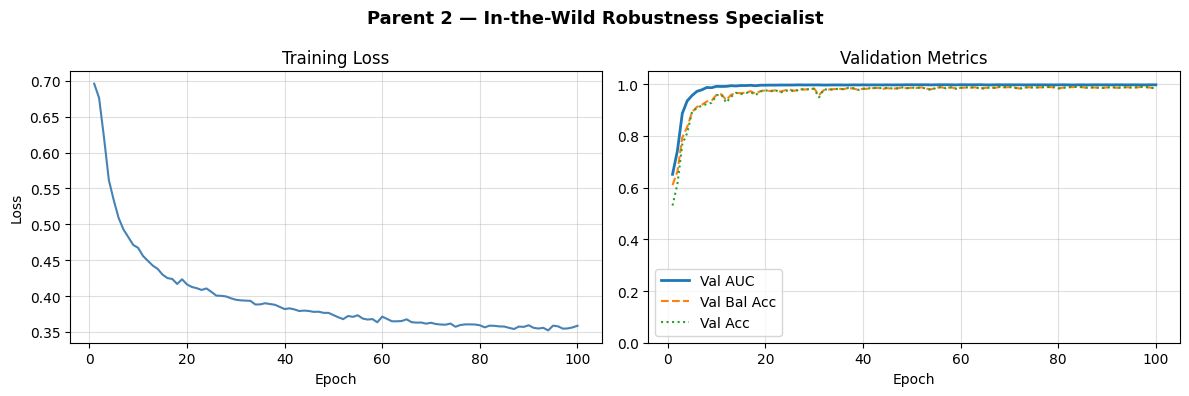

In [18]:
def plot_history(history, title, save_path=None):
    epochs = list(range(1, len(history['val_auc']) + 1))
    has_probe = any(v is not None for v in history.get('probe_auc', []))
    ncols = 3 if has_probe else 2

    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(epochs, history['train_loss'], color='steelblue')
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.4)

    # Val metrics
    axes[1].plot(epochs, history['val_auc'],  label='Val AUC',     lw=2)
    axes[1].plot(epochs, history['val_bal'],  label='Val Bal Acc', ls='--')
    axes[1].plot(epochs, history['val_acc'],  label='Val Acc',     ls=':')
    axes[1].set_title('Validation Metrics')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    # Generalization probe
    if has_probe:
        probe_epochs = [i + 1 for i, v in enumerate(history['probe_auc'])
                        if v is not None]
        probe_vals   = [v for v in history['probe_auc'] if v is not None]
        axes[2].plot(probe_epochs, probe_vals, 'ro-', lw=1.5,
                     label='Deepfake-Eval AUC')
        axes[2].axhline(0.5, color='gray', ls='--', lw=0.8, label='Random')
        axes[2].set_title('Generalization Probe\n(tracking only)')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylim(0, 1.05)
        axes[2].legend()
        axes[2].grid(True, alpha=0.4)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Figure saved → {save_path}')
    plt.show()



if 'p2_history' in dir() and p2_history:
    plot_history(p2_history, 'Parent 2 — In-the-Wild Robustness Specialist',
                 save_path=os.path.join(P2_SAVE_DIR, 'training_curves.png'))

In [19]:
print('=' * 65)
print('  PARENT TRAINING SUMMARY')
print('=' * 65)
for name, save_dir in [('Parent 2 — In-the-Wild Robustness Spec.', P2_SAVE_DIR)]:
    best_path = os.path.join(save_dir, 'best_auc.pth')
    print(f'\n{name}')
    if os.path.isfile(best_path):
        ckpt = torch.load(best_path, map_location='cpu')
        m    = ckpt.get('metrics', {})
        print(f'  Stopped at epoch : {ckpt["epoch"] + 1}')
        print(f'  Best val AUC     : {ckpt["best_auc"]:.4f}')
        print(f'  Val bal acc      : {m.get("bal_acc", float("nan")):.4f}')
        print(f'  Val accuracy     : {m.get("accuracy", float("nan")):.4f}')
        print(f'  File size        : {os.path.getsize(best_path)/1e6:.1f} MB')
        print(f'  Path             : {best_path}')
    else:
        print(f'  ❌ best_auc.pth not found at {save_dir}')
        print(f'     Training may still be in progress or was interrupted.')
print('\n' + '=' * 65)
print('  Pass both best_auc.pth paths into MeGA-IA as CKPT1 and CKPT2.')
print('=' * 65)


  PARENT TRAINING SUMMARY

Parent 2 — In-the-Wild Robustness Spec.
  Stopped at epoch : 60
  Best val AUC     : 0.9983
  Val bal acc      : 0.9862
  Val accuracy     : 0.9862
  File size        : 305.3 MB
  Path             : D:\1230079\checkpoints\parent2_itw\best_auc.pth

  Pass both best_auc.pth paths into MeGA-IA as CKPT1 and CKPT2.


  FINAL TESTING ON DEEPFAKE-EVAL-2024
Loading full Deepfake-Eval Test Set...
DeepfakeProbeDataset: 1,980 files ready.
Evaluating...



--- Deepfake-Eval Results ---
AUC:       0.4826
EER:       0.5191
Accuracy:  0.5626
Precision: 0.5022
Recall:    0.5012
F1 Score:  0.4615
Confusion Matrix:
 [[128 685]
 [181 986]]


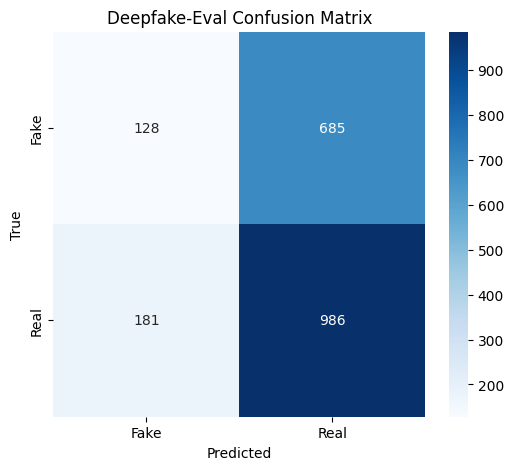

In [20]:
import json
import seaborn as sns
print('=========================================')
print('  FINAL TESTING ON DEEPFAKE-EVAL-2024')
print('=========================================')
best_p2 = os.path.join(P2_SAVE_DIR, 'best_auc.pth')
if os.path.exists(best_p2):
    p2_model.load_state_dict(torch.load(best_p2, map_location=device, weights_only=False)['model_state_dict'])
    
    # Load full deepfake eval, not just probe
    print('Loading full Deepfake-Eval Test Set...')
    df_ds = DeepfakeProbeDataset(DEEPFAKE_META)
    df_loader = DataLoader(df_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
    
    print('Evaluating...')
    results = compute_metrics(p2_model, df_loader)
    
    print('\n--- Deepfake-Eval Results ---')
    print(f"AUC:       {results['auc']:.4f}")
    print(f"EER:       {results['eer']:.4f}")
    print(f"Accuracy:  {results['accuracy']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall:    {results['recall']:.4f}")
    print(f"F1 Score:  {results['f1']:.4f}")
    print("Confusion Matrix:\n", np.array(results['cm']))
    
    with open(os.path.join(P2_SAVE_DIR, 'deepfake_eval_results.json'), 'w') as f:
        json.dump(results, f, indent=4)
        
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(results['cm'], annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.title('Deepfake-Eval Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.savefig(os.path.join(P2_SAVE_DIR, 'deepfake_eval_cm.png'))
    plt.show()
else:
    print('Train Parent 2 first to generate best_auc.pth')


In [ ]:
!git clone https://github.com/AWW4B/DeepSecure-Forensics.git


'git' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
pip install dulwich

     ---------------------------------------- 1.0/1.0 MB 5.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from dulwich import porcelain

repo_url = "https://github.com/AWW4B/DeepSecure-Forensics.git" # Replace with your repo URL
target_dir = "DeepSecure-Forensics" # The folder you want it saved in

# This performs the clone
porcelain.clone(repo_url, target_dir)
print("Clone complete!")


Clone complete!
